# Project 5 North Dakota Pipeline 

**Team:** ENVRN-01-18 **Date:** 05/07/2026

**Client:** Garrison Diverson Project, Red River Valley Water Supply Project (RRVWSP)

In [13]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv("CIVE202_Project5_RRVWSP.csv")

C:\Users\Owner\AppData\Local\Temp\ipykernel_16040\543740593.py:7: DtypeWarning: Columns (5,12,17,19,25,56,59,71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CIVE202_Project5_RRVWSP.csv")


In [3]:
print(df.columns)

Index(['OrganizationIdentifier', 'OrganizationFormalName',
       'ActivityIdentifier', 'ActivityTypeCode', 'ActivityMediaName',
       'ActivityMediaSubdivisionName', 'ActivityStartDate',
       'ActivityStartTime/Time', 'ActivityStartTime/TimeZoneCode',
       'ActivityEndDate', 'ActivityEndTime/Time',
       'ActivityEndTime/TimeZoneCode', 'ActivityRelativeDepthName',
       'ActivityDepthHeightMeasure/MeasureValue',
       'ActivityDepthHeightMeasure/MeasureUnitCode',
       'ActivityDepthAltitudeReferencePointText',
       'ActivityTopDepthHeightMeasure/MeasureValue',
       'ActivityTopDepthHeightMeasure/MeasureUnitCode',
       'ActivityBottomDepthHeightMeasure/MeasureValue',
       'ActivityBottomDepthHeightMeasure/MeasureUnitCode', 'ProjectIdentifier',
       'ProjectName', 'ActivityConductingOrganizationText',
       'MonitoringLocationIdentifier', 'MonitoringLocationName',
       'ActivityCommentText', 'SampleAquifer', 'HydrologicCondition',
       'HydrologicEvent', 'Activi

# Water quality degradation from Lake Sakakawea to the end of the McClusky Canal

In [4]:
# Filter for TDS
tds = df[df['CharacteristicName'] == 'Total dissolved solids']

# Filter for Lake Sakakawea
lake_tds = tds[tds['location_name'] == 'Lake Sakakawea']

# Compute average
lake_avg_tds = lake_tds['ResultMeasureValue'].mean()

print("Average TDS (Lake Sakakawea):", lake_avg_tds)

Average TDS (Lake Sakakawea): 394.6025641025641


In [5]:
print(df['location_name'].unique())

['Lake Sakakawea' 'Lake Ashtabula' 'Turtle Creek-Above Turtle Lake'
 'Sheyenne River - Lisbon' 'Sheyenne River 3' 'Red River'
 'New Johns Lake - Deepest' 'Sheyenne River - Warwick'
 'West Park Lake - Deepest' 'Heckers Lake - Deepest'
 'East Park Lake - Deepest' 'Lake Audubon - Deepest'
 'Red River near Miller Dr N, 2 MI N of Moorhead, MN'
 'Sheyenne River In Lisbon ND' 'Sheyenne River SE of Kindred'
 'Sheyenne River Nr Maddock, ND' 'Sheyenne River Nr Harvey, ND'
 'Sheyenne River 4']


In [6]:
# Average TDS by location
tds_summary = tds.groupby('location_name')['ResultMeasureValue'].mean().sort_values()

print(tds_summary)

location_name
Red River                                              330.000000
Lake Sakakawea                                         394.602564
Red River near Miller Dr N, 2 MI N of Moorhead, MN     473.155000
Sheyenne River SE of Kindred                           484.500000
Lake Audubon - Deepest                                 629.750000
Sheyenne River 4                                       640.000000
Sheyenne River - Warwick                               763.085714
Sheyenne River - Lisbon                                783.321839
West Park Lake - Deepest                               789.571429
Turtle Creek-Above Turtle Lake                         812.897436
Lake Ashtabula                                         902.901060
East Park Lake - Deepest                               914.428571
Sheyenne River In Lisbon ND                            914.836066
Sheyenne River Nr Maddock, ND                          992.333333
Heckers Lake - Deepest                                1122.857

# Dynamic input for Flow Rate and Concentration

# Boxplots for 4 water quality parameters

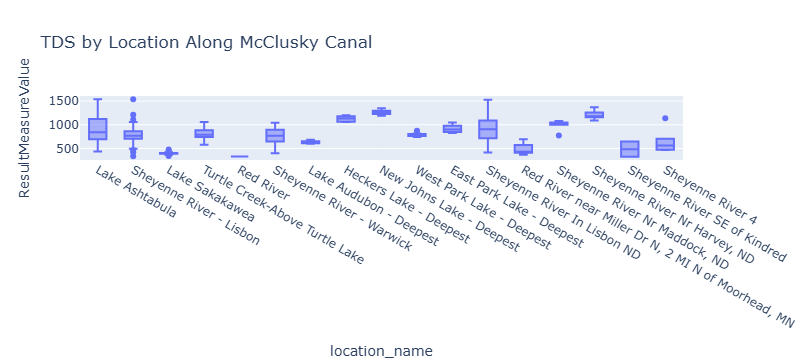

In [18]:
import plotly.express as px

# Filter for TDS
tds = df[df["CharacteristicName"] == "Total dissolved solids"]

fig = px.box(
    tds,
    x="location_name",
    y="ResultMeasureValue",
    title="TDS by Location Along McClusky Canal"
)

fig.show()

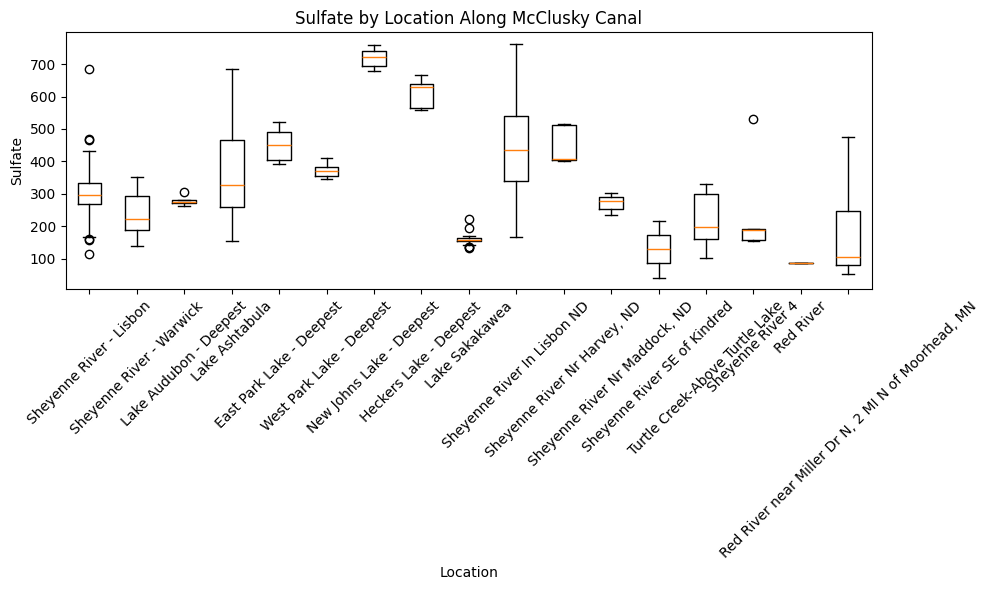

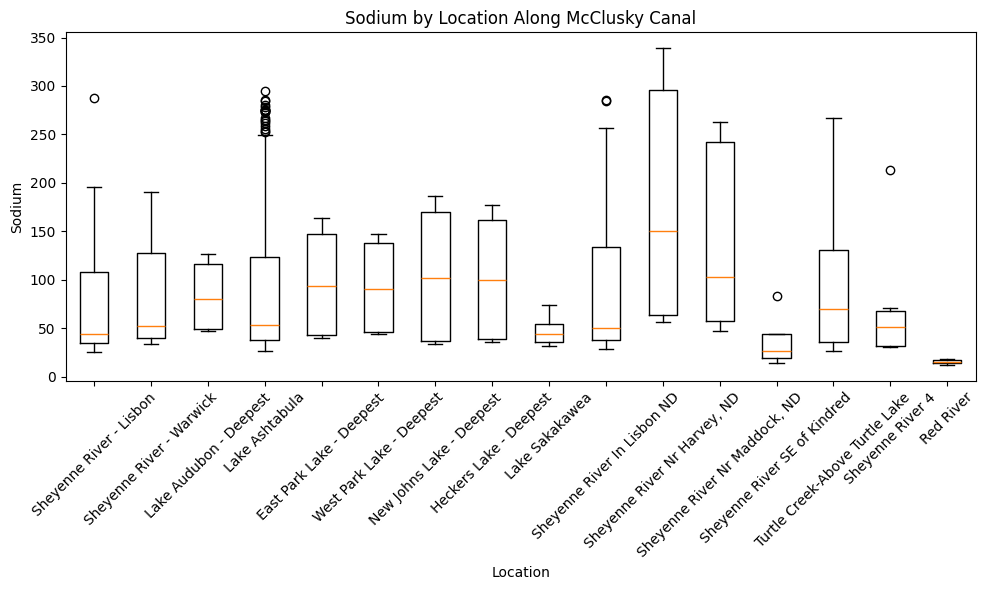

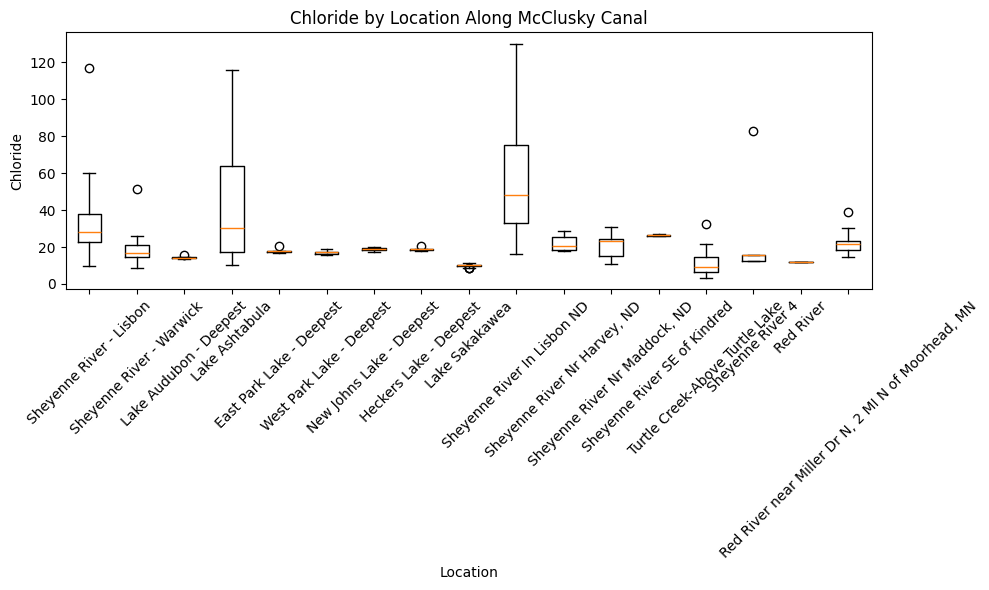

In [23]:
params = [
    "Sulfate",
    "Sodium",
    "Chloride"
]

for param in params:
    temp = df[df["CharacteristicName"] == param].copy()

    locations = (
        temp[["location_order", "location_name"]]
        .drop_duplicates()
        .sort_values("location_order")["location_name"]
        .tolist()
    )

    data = [
        temp[temp["location_name"] == loc]["ResultMeasureValue"].dropna()
        for loc in locations
    ]

    plt.figure(figsize=(10, 6))
    plt.boxplot(data)

    plt.xticks(range(1, len(locations) + 1), locations, rotation=45)
    plt.xlabel("Location")
    plt.ylabel(param)
    plt.title(f"{param} by Location Along McClusky Canal")

    plt.tight_layout()
    plt.show()

# Mean of water quality parameters of interest

In [24]:
# Convert to numeric
df['ResultMeasureValue'] = pd.to_numeric(df['ResultMeasureValue'], errors='coerce')

# Filter only required parameters
params = [
    'Calcium',
    'Magnesium',
    'Sodium',
    'Sodium adsorption ratio [(Na)/(sq root of 1/2 Ca + Mg)]',
    'Chloride',
    'Sulfate',
    'Carbonate',
    'Bicarbonate',
    'Total dissolved solids',
    'pH',
    'Hardness, carbonate',
]

wq = df[df['CharacteristicName'].isin(params)].copy()

# Summary statistics
summary = (
    wq.groupby(['CharacteristicName'])['ResultMeasureValue']
    .agg(mean='mean', median='median', max='max', min='min')
    .reset_index()
    .sort_values(['CharacteristicName'])
)

print(summary)

                                   CharacteristicName        mean   median  \
0                                         Bicarbonate  373.518355  358.000   
1                                             Calcium   70.404545   72.250   
2                                           Carbonate   13.490323   12.000   
3                                            Chloride   31.775079   21.100   
4                                 Hardness, carbonate  412.049853  419.000   
5                                           Magnesium   57.362757   55.050   
6                                              Sodium   83.339223   50.650   
7   Sodium adsorption ratio [(Na)/(sq root of 1/2 ...    2.700924    2.495   
8                                             Sulfate  316.249714  292.500   
9                              Total dissolved solids  809.311201  777.000   
10                                                 pH    8.303372    8.320   

        max     min  
0    786.00  157.00  
1    134.00   21.50